In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
import glob
import os

In [2]:
def pseudo_voigt_matlab(x, A, x0, w, background, mu):
    # Gaussian contribution:
    yG = mu * A * norm.pdf(x, loc=x0, scale=w)

    # Lorentziation contribution:
    yL = (1 - mu) * A * (1/np.pi) * (w/2) / ((x - x0)**2 + (w/2)**2)

    return yG + yL + background


def fit_pseudoVoigt_matlab(xdata, ydata):
    ymin = np.min(ydata)
    dx = xdata[1] - xdata[0]

    A0 = np.sum(ydata - ymin) * dx  # A
    x0_0 = xdata[np.argmax(ydata)]  # x0
    w0 = (xdata[-1] - xdata[0]) / 10 # Width
    background0 = ymin              # Background
    mu0 = 0.5                       # Relative weight, Gauss.

    p0 = [A0, x0_0, w0, background0, mu0]

    popt, pcov = curve_fit(pseudo_voigt_matlab, xdata, ydata, p0)

    xfit = xdata
    yfit = pseudo_voigt_matlab(xfit, *popt)

    return popt, xfit, yfit

def peakSummation(x, peakPosVec, peakStrengthVec, peakWidth, mu):
    y_total = np.zeros_like(x)

    for pos, strength in zip(peakPosVec, peakStrengthVec):

        # Gaussian part
        yG = mu * strength * norm.pdf(x, loc=pos, scale=peakWidth)

        # Lorentzian part
        yL = (1 - mu) * strength * (1/np.pi) * (peakWidth/2) / ((x - pos)**2 + (peakWidth/2)**2)

        y_total += (yG + yL)

    return y_total

In [3]:
lambda_A = 1.54056 # Wavelength in Ångström

files = glob.glob("DATA/DATA/heating*")

def extract_temp(fname):
    base = os.path.basename(fname)
    temp_str = base.split("_")[-1].replace("C.txt", "")
    return int(temp_str)

files = sorted(files, key=extract_temp)

print("Found files:", files)

M = []
for f in files:         # Loade the data
    data = np.loadtxt(f, skiprows=1)
    M.append(data)

M = np.stack(M, axis=2)

T = np.array([extract_temp(f) for f in files])

Found files: ['DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_100C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_150C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_200C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_250C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_300C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_350C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_400C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_450C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_500C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_550C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_600C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_650C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_700C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_750C.txt', 'DATA/DATA\\heating_100-950deg_20-70deg_14min_exported_800C.tx

In [4]:
%matplotlib widget

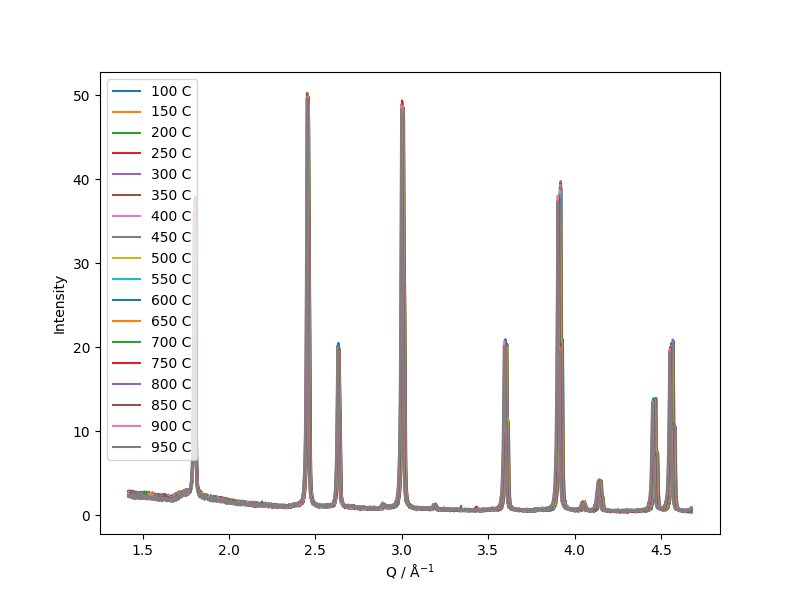

In [10]:
plt.figure(figsize=(8,6))
for jj in range(len(T)):
    theta = M[:,0,jj]
    intensity = M[:,1,jj]
    Q = 4*np.pi/lambda_A * np.sin(np.deg2rad(theta/2))
    plt.plot(Q, intensity, label=f"{T[jj]} C") # Plot as function of Q
    # plt.plot(theta, intensity, label=f"{T[jj]} C (theta)") # Plot as function of theta
plt.xlabel("Q / Å$^{-1}$")
plt.ylabel("Intensity")
plt.legend()
plt.show()


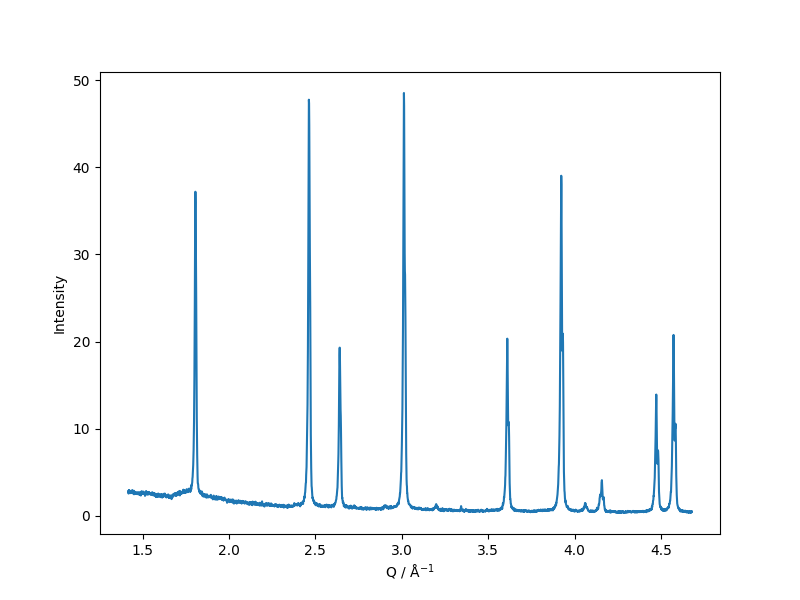

In [6]:
plt.figure(figsize=(8,6))
theta = M[:,0,0]
I = M[:,1,0]
Q = 4*np.pi/lambda_A * np.sin(np.deg2rad(theta/2))
plt.plot(Q, I)
plt.xlabel("Q / Å$^{-1}$")
plt.ylabel("Intensity")
plt.show()


### Analysis {1 1 0}

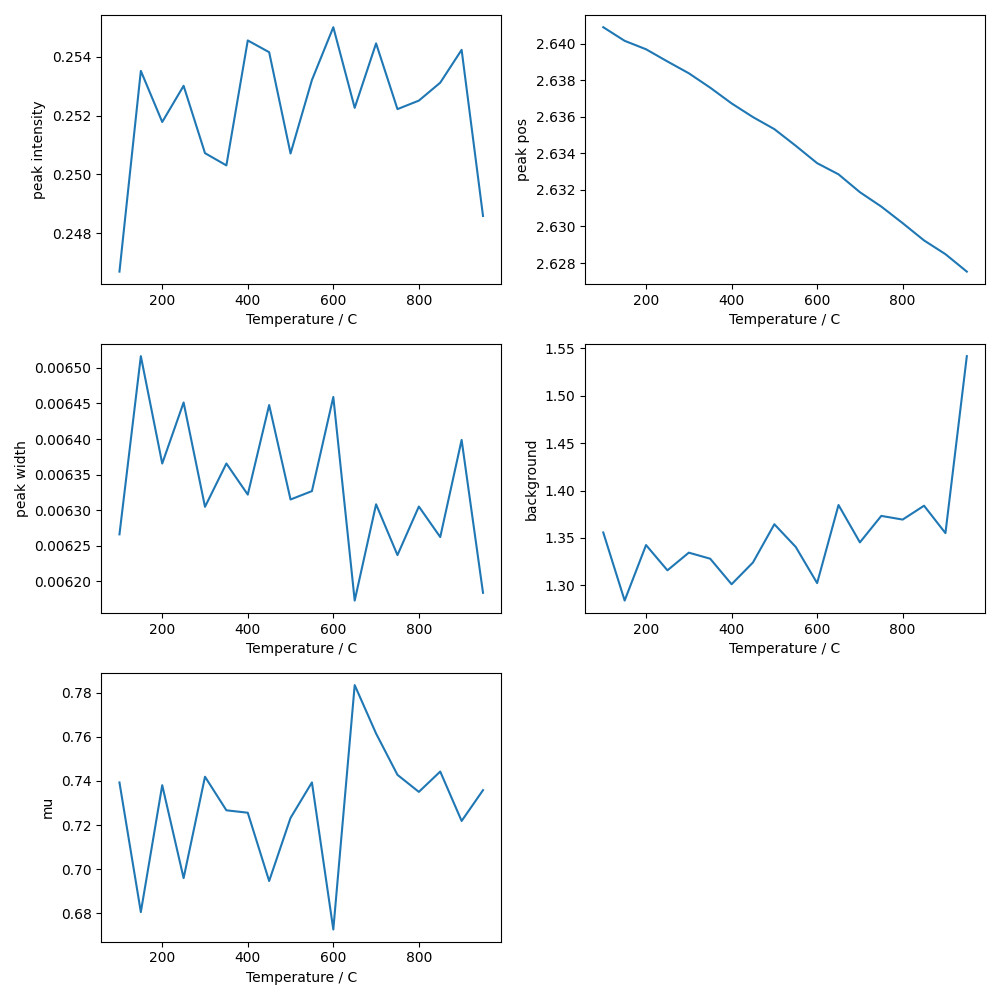

In [7]:
XM = []

for jj in range(len(T)):
    theta = M[:,0,jj]
    I = M[:,1,jj]
    Q = 4*np.pi/lambda_A * np.sin(np.deg2rad(theta/2))

    mask = (Q > 2.60) & (Q < 2.66) # {1 1 3} reflections
    xdata = Q[mask]
    ydata = I[mask]

    Xjj, xfit, yfit = fit_pseudoVoigt_matlab(xdata, ydata)
    XM.append(Xjj)

XM = np.array(XM)

fig, axs = plt.subplots(3,2, figsize=(10,10))
axs[0,0].plot(T, XM[:,0]); axs[0,0].set_ylabel("peak intensity")
axs[0,1].plot(T, XM[:,1]); axs[0,1].set_ylabel("peak pos")
axs[1,0].plot(T, XM[:,2]); axs[1,0].set_ylabel("peak width")
axs[1,1].plot(T, XM[:,3]); axs[1,1].set_ylabel("background")
axs[2,0].plot(T, XM[:,4]); axs[2,0].set_ylabel("mu")
axs[2,1].remove()
for ax in axs.flat: ax.set_xlabel("Temperature / C")
plt.tight_layout()
plt.show()


### Analysis {1 1 3} Q=3.01 Å$^{-1}$

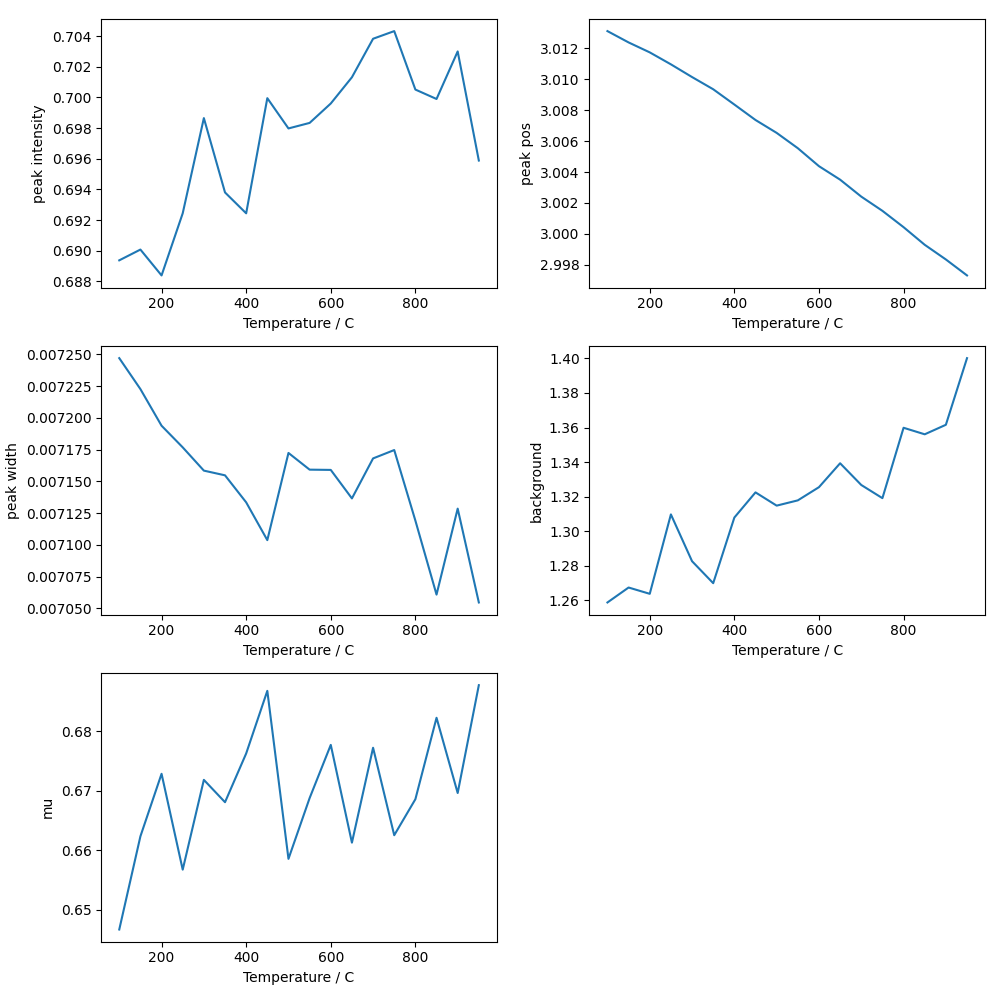

In [8]:
XM2 = []

for jj in range(len(T)):
    theta = M[:,0,jj]
    I = M[:,1,jj]
    Q = 4*np.pi/lambda_A * np.sin(np.deg2rad(theta/2))

    # mask = (Q > 1.77) & (Q < 1.84) # {1 0 2} reflections
    mask = (Q > 2.96) & (Q < 3.04) # {1 1 3} reflections
    xdata = Q[mask]
    ydata = I[mask]

    Xjj, xfit, yfit = fit_pseudoVoigt_matlab(xdata, ydata)
    XM2.append(Xjj)

XM2 = np.array(XM2)

fig, axs = plt.subplots(3,2, figsize=(10,10))
axs[0,0].plot(T, XM2[:,0]); axs[0,0].set_ylabel("peak intensity")
axs[0,1].plot(T, XM2[:,1]); axs[0,1].set_ylabel("peak pos")
axs[1,0].plot(T, XM2[:,2]); axs[1,0].set_ylabel("peak width")
axs[1,1].plot(T, XM2[:,3]); axs[1,1].set_ylabel("background")
axs[2,0].plot(T, XM2[:,4]); axs[2,0].set_ylabel("mu")
axs[2,1].remove()
for ax in axs.flat: ax.set_xlabel("Temperature / C")
plt.tight_layout()
plt.show()


### Calculate Lattice parameters a(T), c(T) and V(T)

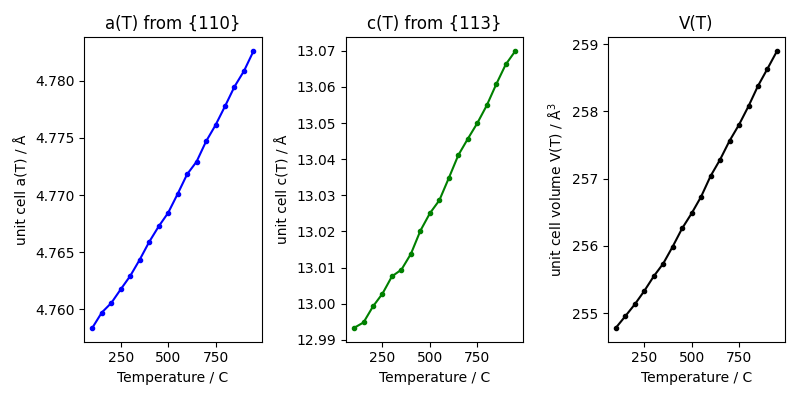

In [9]:
# Calculate lattice parameter a:
# 1/d^2 = 4/3 (h^2 + hk + k^2)/ a^2 + l^2/c^2
Q110 = XM[:,1]
d110 = 2*np.pi / Q110
uc_a = 2*d110

# Calculate lattice parameter c:
# 1/d^2 = 4/3 (h^2 + hk + k^2)/ a^2 + l^2/c^2
Q113 = XM2[:,1]
d113 = 2*np.pi / Q113
uc_c = 3*uc_a * d113 / np.sqrt(uc_a**2 - 4*d113**2)

# Calculate unit cell volume V(t):
# V = a^2*c*sqrt(3)/2
Vc = uc_a**2 * uc_c * np.sqrt(3) / 2

fig, axs = plt.subplots(1, 3, figsize=(8, 4))

# a(T)
axs[0].plot(T, uc_a, "b.-")
axs[0].set_xlabel("Temperature / C")
axs[0].set_ylabel("unit cell a(T) / Å")
axs[0].set_title("a(T) from {110}")

# c(T)
axs[1].plot(T, uc_c, "g.-")
axs[1].set_xlabel("Temperature / C")
axs[1].set_ylabel("unit cell c(T) / Å")
axs[1].set_title("c(T) from {113}")

# V(T)
axs[2].plot(T, Vc, "k.-")
axs[2].set_xlabel("Temperature / C")
axs[2].set_ylabel(r"unit cell volume V(T) / Å$^3$")
axs[2].set_title("V(T)")

plt.tight_layout()
plt.show()
